# 03 — Baseline Models

**Project:** MeetingMind | **Phase:** 3

## ML problem
Given one meeting utterance (plus optionally its neighbours), predict whether it supports a summary **action**, **decision**, **problem**, or is **other**.

## Why baselines first
A fine-tuned transformer is only impressive if it beats cheap models. We build the cheap ones now:

| # | Model | Question it answers |
|---|---|---|
| 0 | Majority class | What does "accuracy" hide? |
| 1 | Length only | How much is just "long utterance = important"? |
| 2 | TF-IDF (utterance) + length | How far do words alone go? |
| 3 | TF-IDF (utterance + context window) + length | Does neighbouring text help? |

## Rules in this notebook
- Model selection uses **validation** only. The **test split is never touched** until the final evaluation (notebook 05).
- `da_type` and the `link_*` columns are **not** features (they would leak the label or are unavailable at inference).
- Metrics are per-class precision/recall/F1, average precision (PR-AUC), and macro-F1 over the three positive classes. Accuracy is reported only to show it is misleading.
- Variance is estimated with **session-grouped cross-validation** on train+val, because the validation set has very few positives.

## 1. Imports and configuration

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             precision_recall_fscore_support)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
POSITIVE_CLASSES = ["action", "decision", "problem"]
CONTEXT_WINDOW = 2   # utterances before and after

## 2. Load data
`other` dominates, so we expect heavy imbalance. We also build a **context** field: the text of the 2 previous and 2 next utterances in the same meeting, ordered by start time (speakers interleaved). Context never crosses meetings, and splits are by session, so context never crosses splits either.

Note: in the real pipeline the whole transcript is available offline, so using *following* utterances is legitimate.

In [3]:
df = pd.read_csv(PROCESSED_DIR / "ami_labeled.csv")
df["text"] = df["text"].fillna("").astype(str)

print("Rows with missing start time:", df["start"].isna().sum())
df = df.sort_values(["meeting_id", "start"], na_position="last", kind="stable").reset_index(drop=True)

grouped_text = df.groupby("meeting_id")["text"]
context_parts = []
for offset in list(range(-CONTEXT_WINDOW, 0)) + list(range(1, CONTEXT_WINDOW + 1)):
    context_parts.append(grouped_text.shift(-offset).fillna(""))   # shift(-k) looks k rows ahead
df["context"] = pd.concat(context_parts, axis=1).agg(" ".join, axis=1).str.strip()

df["log_n_words"] = np.log1p(df["n_words"])

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
trainval_df = df[df["split"].isin(["train", "val"])].reset_index(drop=True)
# NOTE: df[df.split == 'test'] is intentionally never used in this notebook.

print(pd.crosstab(df["split"], df["label"]).loc[["train", "val", "test"]])
print("\nExample row with context:")
print(df.loc[df["label"] == "decision"].iloc[0][["text", "context"]].to_dict())

Rows with missing start time: 0
label  action  decision  other  problem
split                                  
train     256       932  73080     1604
val        56       203  14474      298
test       69       215  16909      252

Example row with context:
{'text': "Um so according to the brief um we're gonna be selling this remote control for twenty five Euro,", 'context': "Um what are we doing next? Uh um. Okay, uh we now need to discuss the project finance. um and we're aiming to make fifty million Euro. Um so we're gonna be selling this on an international scale."}


## 3. Evaluation helper
- **Per-class precision / recall / F1** for action, decision, problem
- **Macro-F1 (positive classes)**: mean of the three F1s. `other` is excluded, otherwise it would dominate.
- **Average precision (AP)**: area under the precision-recall curve per class. Threshold-free, so it shows ranking quality, which matters for rare classes.
- **Binary F1 (decision or action)**: collapses the two classes MeetingMind actually outputs.
- **Accuracy**: included only to show it misleads.

In [4]:
def evaluate(y_true, y_pred, proba, classes) -> dict:
    """Return a flat dict of metrics. `proba` columns follow `classes` order."""
    y_true, y_pred, classes = np.asarray(y_true), np.asarray(y_pred), list(classes)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=POSITIVE_CLASSES, zero_division=0)
    result = {"accuracy": accuracy_score(y_true, y_pred), "macro_f1_pos": f.mean()}
    for c, pi, ri, fi in zip(POSITIVE_CLASSES, p, r, f):
        result[f"P_{c}"], result[f"R_{c}"], result[f"F1_{c}"] = pi, ri, fi
        is_c = (y_true == c).astype(int)
        result[f"AP_{c}"] = average_precision_score(is_c, proba[:, classes.index(c)]) if is_c.any() else np.nan

    # Binary: decision-or-action
    target = np.isin(y_true, ["action", "decision"])
    predicted = np.isin(y_pred, ["action", "decision"])
    tp = (target & predicted).sum()
    prec = tp / predicted.sum() if predicted.sum() else 0.0
    rec = tp / target.sum() if target.sum() else 0.0
    result["P_da"], result["R_da"] = prec, rec
    result["F1_da"] = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    score = proba[:, classes.index("action")] + proba[:, classes.index("decision")]
    result["AP_da"] = average_precision_score(target.astype(int), score) if target.any() else np.nan
    return result

## 4. Model definitions
All models are scikit-learn pipelines so that the vectorizer is **fit only on the training fold**. This is the standard way to avoid preprocessing leakage.

- `class_weight="balanced"`: reweights the loss by inverse class frequency. It improves recall of rare classes but typically lowers precision. We handle thresholds later.
- TF-IDF with word 1-2 grams, `sublinear_tf` to dampen repeated words, `min_df` to drop one-off tokens.

In [5]:
def make_tfidf(max_features: int) -> TfidfVectorizer:
    return TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=max_features,
                           sublinear_tf=True, lowercase=True)


def make_classifier() -> LogisticRegression:
    return LogisticRegression(class_weight="balanced", max_iter=300, C=1.0, random_state=RANDOM_SEED)


def build_model(kind: str) -> Pipeline:
    if kind == "majority":
        return Pipeline([("clf", DummyClassifier(strategy="most_frequent"))])
    if kind == "length_only":
        features = ColumnTransformer([("len", StandardScaler(), ["log_n_words"])])
    elif kind == "tfidf_utterance":
        features = ColumnTransformer([("cur", make_tfidf(50_000), "text"),
                                      ("len", StandardScaler(), ["log_n_words"])])
    elif kind == "tfidf_context":
        features = ColumnTransformer([("cur", make_tfidf(50_000), "text"),
                                      ("ctx", make_tfidf(50_000), "context"),
                                      ("len", StandardScaler(), ["log_n_words"])])
    else:
        raise ValueError(kind)
    return Pipeline([("features", features), ("clf", make_classifier())])


MODEL_KINDS = ["majority", "length_only", "tfidf_utterance", "tfidf_context"]
FEATURE_COLUMNS = ["text", "context", "log_n_words"]

## 5. Train on train, evaluate on validation
Training takes about a minute per TF-IDF model. `ConvergenceWarning` from the logistic regression is not fatal; if it appears we will raise `max_iter` or check scaling.

In [6]:
fitted, val_results, val_predictions = {}, {}, {}
for kind in MODEL_KINDS:
    model = build_model(kind)
    model.fit(train_df[FEATURE_COLUMNS], train_df["label"])
    classes = model.classes_ if hasattr(model, "classes_") else model.named_steps["clf"].classes_
    proba = model.predict_proba(val_df[FEATURE_COLUMNS])
    pred = model.predict(val_df[FEATURE_COLUMNS])
    fitted[kind] = model
    val_predictions[kind] = (pred, proba, classes)
    val_results[kind] = evaluate(val_df["label"], pred, proba, classes)
    print(f"done: {kind}")

results_table = pd.DataFrame(val_results).T
results_table.round(3)

done: majority
done: length_only
done: tfidf_utterance
done: tfidf_context


,accuracy,macro_f1_pos,P_action,R_action,F1_action,AP_action,P_decision,R_decision,F1_decision,AP_decision,P_problem,R_problem,F1_problem,AP_problem,P_da,R_da,F1_da,AP_da
majority,0.963,0.000,0.000,0.000,0.000,0.004,0.000,0.000,0.000,0.014,0.000,0.000,0.000,0.020,0.000,0.000,0.000,0.017
length_only,0.650,0.049,0.000,0.000,0.000,0.009,0.023,0.340,0.043,0.026,0.058,0.460,0.103,0.057,0.032,0.363,0.058,0.035
tfidf_utterance,0.827,0.168,0.170,0.696,0.274,0.305,0.071,0.355,0.118,0.069,0.069,0.302,0.113,0.063,0.092,0.444,0.153,0.131
tfidf_context,0.902,0.224,0.298,0.661,0.411,0.452,0.098,0.241,0.139,0.088,0.089,0.188,0.121,0.078,0.144,0.347,0.203,0.181


In [7]:
summary_cols = ["accuracy", "macro_f1_pos", "F1_action", "F1_decision", "F1_problem",
                "AP_action", "AP_decision", "AP_problem", "P_da", "R_da", "F1_da", "AP_da"]
print("Validation results (sorted by macro-F1 over action/decision/problem):")
display_table = results_table[summary_cols].sort_values("macro_f1_pos", ascending=False).round(3)
display_table

Validation results (sorted by macro-F1 over action/decision/problem):


,accuracy,macro_f1_pos,F1_action,F1_decision,F1_problem,AP_action,AP_decision,AP_problem,P_da,R_da,F1_da,AP_da
tfidf_context,0.902,0.224,0.411,0.139,0.121,0.452,0.088,0.078,0.144,0.347,0.203,0.181
tfidf_utterance,0.827,0.168,0.274,0.118,0.113,0.305,0.069,0.063,0.092,0.444,0.153,0.131
length_only,0.650,0.049,0.000,0.043,0.103,0.009,0.026,0.057,0.032,0.363,0.058,0.035
majority,0.963,0.000,0.000,0.000,0.000,0.004,0.014,0.020,0.000,0.000,0.000,0.017


### How to read this table
- `majority`: accuracy is ~96% while every F1 is 0. This is why accuracy is not used for model selection.
- `length_only`: a nonzero F1 here is the **floor** any text model must clearly beat.
- Compare `tfidf_utterance` and `tfidf_context`. If `tfidf_context` improves recall on `action`/`decision`, single utterances alone are not enough, which affects the design of the fine-tuned model.
- Validation has few positives (see the counts above). Treat small differences as noise, and look at the cross-validation section.

## 6. Confusion matrix (best model by validation macro-F1)
Rows are true labels, columns are predictions. Look for: where do `decision` and `action` go wrong? `problem` and `decision` confusion is expected, and it is why `problem` is kept as a class.

Best on validation: tfidf_context


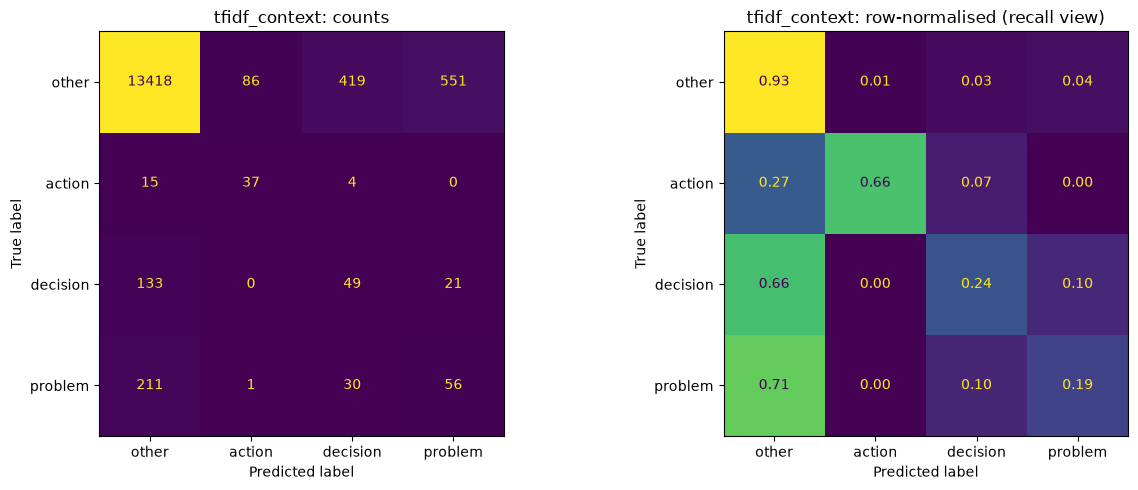

In [8]:
best_kind = results_table.drop(index="majority")["macro_f1_pos"].idxmax()
print("Best on validation:", best_kind)

pred, proba, classes = val_predictions[best_kind]
label_order = ["other", "action", "decision", "problem"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(val_df["label"], pred, labels=label_order, ax=axes[0],
                                        colorbar=False, values_format="d")
axes[0].set_title(f"{best_kind}: counts")
ConfusionMatrixDisplay.from_predictions(val_df["label"], pred, labels=label_order, ax=axes[1],
                                        normalize="true", colorbar=False, values_format=".2f")
axes[1].set_title(f"{best_kind}: row-normalised (recall view)")
plt.tight_layout()
plt.show()

## 7. Precision-recall curves (decision or action)
A threshold-free view. Each curve shows the precision you get at a given recall when ranking utterances by P(action) + P(decision). The dotted line is the positive rate: a random ranker's precision.

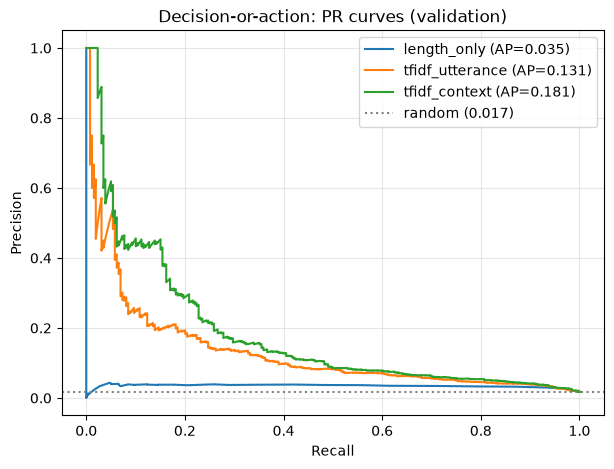

In [9]:
target_da = val_df["label"].isin(["action", "decision"]).astype(int).values
plt.figure(figsize=(7, 5))
for kind in ["length_only", "tfidf_utterance", "tfidf_context"]:
    _, proba_k, classes_k = val_predictions[kind]
    classes_k = list(classes_k)
    score = proba_k[:, classes_k.index("action")] + proba_k[:, classes_k.index("decision")]
    precision, recall, _ = precision_recall_curve(target_da, score)
    plt.plot(recall, precision, label=f"{kind} (AP={average_precision_score(target_da, score):.3f})")
plt.axhline(target_da.mean(), ls=":", color="gray", label=f"random ({target_da.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Decision-or-action: PR curves (validation)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. What did the model learn? (top features)
Coefficients show which tokens push toward each class. Look for:
- Sensible cues ("we will", "need to", "decided", "go with"), which is real signal.
- Meeting-specific words ("remote", "banana", names), which suggest overfitting to the AMI design scenario and a domain-shift risk for real meetings.

In [10]:
model = fitted[best_kind]
if best_kind != "majority":
    feature_names = model.named_steps["features"].get_feature_names_out()
    coefs = model.named_steps["clf"].coef_
    class_list = list(model.named_steps["clf"].classes_)
    for c in POSITIVE_CLASSES:
        top = np.argsort(coefs[class_list.index(c)])[::-1][:15]
        print(f"\n{c.upper()}: ", [feature_names[i] for i in top])


ACTION:  ['cur__work', 'cur__questionnaire', 'cur__report', 'cur__will', 'cur__write', 'ctx__ll', 'cur__designer', 'ctx__work', 'cur__working', 'cur__our own', 'cur__some', 'cur__department', 'cur__minutes', 'cur__final', 'cur__user']

DECISION:  ['cur__plastic', 'cur__waterproof', 'cur__buttons', 'cur__single', 'cur__rubber', 'cur__beep', 'ctx__um we', 'cur__teletext', 'cur__not too', 'ctx__we have', 'cur__recharger', 'cur__potato', 'ctx__what about', 'ctx__shape', 'cur__wall']

PROBLEM:  ['cur__problem', 'ctx__but', 'ctx__yeah sure', 'cur__expensive', 'ctx__is not', 'ctx__visual', 'ctx__it no', 'cur__fruit', 'cur__one would', 'cur__th think', 'ctx__no', 'cur__is not', 'cur__unit', 'cur__yellow', 'cur__television']


## 9. Error analysis
**Remember the label limitation:** only utterances linked to the extractive summary are positive. A confident false positive may actually be an unlabeled *true* decision or action. Read these before concluding the model is wrong.

In [11]:
pred, proba, classes = val_predictions[best_kind]
classes = list(classes)
da_score = proba[:, classes.index("action")] + proba[:, classes.index("decision")]
val_view = val_df.assign(pred=pred, da_score=da_score)

pd.set_option("display.max_colwidth", 150)
false_pos = val_view[(val_view["label"] == "other") & val_view["pred"].isin(["action", "decision"])]
false_neg = val_view[val_view["label"].isin(["action", "decision"]) & ~val_view["pred"].isin(["action", "decision"])]
print(f"False positives: {len(false_pos)} | False negatives: {len(false_neg)}")

print("\n--- Most confident false positives (check: are they secretly real decisions/actions?) ---")
for _, r in false_pos.sort_values("da_score", ascending=False).head(12).iterrows():
    print(f"[{r['meeting_id']} p={r['da_score']:.2f} pred={r['pred']}] {r['text']}")

print("\n--- Missed decisions/actions (random sample) ---")
for _, r in false_neg.sample(min(12, len(false_neg)), random_state=3).iterrows():
    print(f"[{r['meeting_id']} true={r['label']} p={r['da_score']:.2f}] {r['text']}")

False positives: 505 | False negatives: 169

--- Most confident false positives (check: are they secretly real decisions/actions?) ---
[ES2014a p=0.99 pred=action] And I guess I'll try and write up some minutes of uh this meeting to uh to give it to you for the next meeting.
[ES2016b p=0.97 pred=action] Then we can come back and uh work on our individual work.
[ES2013a p=0.97 pred=action] And user, that's you S Steph, for the technical functions design,
[ES2013a p=0.97 pred=action] that's Kate, for the working design.
[ES2013c p=0.97 pred=decision] um and that it include the l so slogan and colour of the uh corporate design be included. Um the corporate image.
[TS3011c p=0.96 pred=decision] We have decided we wanted to use the rubber?
[ES2013b p=0.96 pred=action] and I'll put some minutes of this meeting together.
[TS3011c p=0.96 pred=decision] Uh the previous ideas were voice recognition and uh the round button for uh the p channel programming and uh volume.
[ES2013c p=0.95 pred=actio

## 10. Session-grouped cross-validation (variance estimate)
Validation has few positives, so one number is unreliable. We run 5-fold `GroupKFold` over train+val, **grouped by session**, so no session appears in both a fold's train and its held-out part. The test split is still excluded.

Report mean ± std across folds. If two models' ranges overlap heavily, we cannot claim one is better.

In [12]:
cv_models = ["length_only", "tfidf_utterance", "tfidf_context"]
gkf = GroupKFold(n_splits=5)
cv_rows = []

for kind in cv_models:
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(trainval_df, trainval_df["label"], trainval_df["session_id"])):
        tr, te = trainval_df.iloc[tr_idx], trainval_df.iloc[te_idx]
        model = clone(build_model(kind))
        model.fit(tr[FEATURE_COLUMNS], tr["label"])
        proba = model.predict_proba(te[FEATURE_COLUMNS])
        pred = model.predict(te[FEATURE_COLUMNS])
        metrics = evaluate(te["label"], pred, proba, model.named_steps["clf"].classes_)
        cv_rows.append({"model": kind, "fold": fold, **metrics})
    print("cv done:", kind)

cv_df = pd.DataFrame(cv_rows)
cv_summary = cv_df.groupby("model")[["macro_f1_pos", "F1_action", "F1_decision", "F1_problem", "F1_da", "AP_da"]]\
    .agg(["mean", "std"]).round(3)
cv_summary

cv done: length_only
cv done: tfidf_utterance
cv done: tfidf_context


macro_f1_pos        F1_action        F1_decision         \
                        mean    std      mean    std        mean    std   
model                                                                     
length_only            0.054  0.009     0.011  0.007       0.040  0.005   
tfidf_context          0.214  0.028     0.352  0.072       0.145  0.022   
tfidf_utterance        0.158  0.016     0.233  0.044       0.115  0.016   

                F1_problem         F1_da         AP_da         
                      mean    std   mean    std   mean    std  
model                                                          
length_only          0.111  0.031  0.056  0.011  0.042  0.005  
tfidf_context        0.144  0.011  0.191  0.028  0.157  0.036  
tfidf_utterance      0.127  0.015  0.144  0.015  0.118  0.018

## 11. Save results
These numbers go into the README later. They are baselines, not final results.

In [13]:
display_table.to_csv(REPORTS_DIR / "baseline_validation_results.csv")
cv_df.to_csv(REPORTS_DIR / "baseline_cv_folds.csv", index=False)
print("Saved to", REPORTS_DIR)

Saved to c:\Users\Harijith\Downloads\reports


## 12. Findings summary (paste this back)

In [14]:
print("=== FINDINGS TO REPORT ===")
print(display_table[["accuracy", "macro_f1_pos", "F1_action", "F1_decision", "F1_problem", "F1_da", "AP_da"]].to_string())
print()
print("CV macro_f1_pos (mean +- std):")
for kind in cv_models:
    s = cv_df.loc[cv_df["model"] == kind, "macro_f1_pos"]
    print(f"  {kind:<18} {s.mean():.3f} +- {s.std():.3f}")
print("CV F1_da (mean +- std):")
for kind in cv_models:
    s = cv_df.loc[cv_df["model"] == kind, "F1_da"]
    print(f"  {kind:<18} {s.mean():.3f} +- {s.std():.3f}")
print("Best on validation:", best_kind)
print("ALSO PASTE: section 8 top features, section 9 error examples, and (still) notebook 02 section 8 examples.")

=== FINDINGS TO REPORT ===
                 accuracy  macro_f1_pos  F1_action  F1_decision  F1_problem  F1_da  AP_da
tfidf_context       0.902         0.224      0.411        0.139       0.121  0.203  0.181
tfidf_utterance     0.827         0.168      0.274        0.118       0.113  0.153  0.131
length_only         0.650         0.049      0.000        0.043       0.103  0.058  0.035
majority            0.963         0.000      0.000        0.000       0.000  0.000  0.017

CV macro_f1_pos (mean +- std):
  length_only        0.054 +- 0.009
  tfidf_utterance    0.158 +- 0.016
  tfidf_context      0.214 +- 0.028
CV F1_da (mean +- std):
  length_only        0.056 +- 0.011
  tfidf_utterance    0.144 +- 0.015
  tfidf_context      0.191 +- 0.028
Best on validation: tfidf_context
ALSO PASTE: section 8 top features, section 9 error examples, and (still) notebook 02 section 8 examples.


## Next
Notebook 04 (fine-tuning) will be justified or redirected by these numbers:
- If `tfidf_context` clearly beats `tfidf_utterance`, the transformer gets a context window input.
- If everything is close to `length_only`, labels or task definition need rethinking before spending GPU time.
- Fine-tune DistilBERT/DeBERTa-small on Colab, with class-weighted loss, compared against these baselines and a zero-shot LLM.